In [1]:
import numpy, pandas, sklearn, torch, transformers
print("numpy        :", numpy.__version__)
print("pandas       :", pandas.__version__)
print("scikit-learn :", sklearn.__version__)
print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)

numpy        : 1.26.4
pandas       : 2.2.3
scikit-learn : 1.5.2
torch        : 2.9.1
transformers : 4.57.3


In [32]:
from pathlib import Path

GOEMOTIONS_CSVS = [
    "archive (7)/data/full_dataset/goemotions_1.csv",
    "archive (7)/data/full_dataset/goemotions_2.csv",
    "archive (7)/data/full_dataset/goemotions_3.csv",
]
GOEMO_TEXT_COL  = "text"      

ARTEMIS_CSV     = "official_data/artemis_caption_label.csv"
ART_TEXT_COL    = "caption"
ART_LABEL_COL   = "label"

# ---- Training and mapping params ----
BASE_MODEL = "distilbert-base-uncased"  
EPOCHS     = 2                        
BATCH_SIZE = 8                         
LR         = 3e-5
VAL_SIZE   = 0.1
SEED       = 42
MAX_LEN    = 128                  

OUT_GOEMO  = Path("./out_goemo_1")   # trained classifier
OUT_MAP    = Path("./out_map_1")     # learned mapping + heatmaps
OUT_GOEMO.mkdir(parents=True, exist_ok=True)
OUT_MAP.mkdir(parents=True, exist_ok=True)

ARTEMIS_9 = ['something else','sadness','contentment','awe','amusement','excitement','fear','disgust','anger']


In [3]:
import pandas as pd

src = "official_data/artemis_dataset_release_v0.csv" 
df = pd.read_csv(src)
# columns: 'utterance' (text), 'emotion' (label)
out = df[['utterance','emotion']].rename(columns={'utterance':'caption','emotion':'label'})
out['label'] = (out['label'].astype(str).str.strip().str.lower()
                .str.replace('_',' ', regex=False).str.replace('-',' ', regex=False)
                .str.replace(r'\s+',' ', regex=True))
out.to_csv("official_data/artemis_caption_label.csv", index=False)
print(out.head(), "\nSaved -> official_data/artemis_caption_label.csv")

                                             caption           label
0  She seems very happy in the picture, and you w...  something else
1  This woman has really knotty hands which makes...         sadness
2  When looking at this woman, I am filled with c...  something else
3  A woman looking at ease, peaceful, and satisfi...     contentment
4  She looks like a lady from that past that migh...             awe 
Saved -> official_data/artemis_caption_label.csv


In [4]:
# ==== Multi-label training for GoEmotions CSVs (27 classes with one-hot columns) ====
import json, numpy as np, pandas as pd, torch
from typing import List
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)

assert len(GOEMOTIONS_CSVS) > 0, "Please set GOEMOTIONS_CSVS to your CSV paths."

# The 27 GoEmotions labels (columns in your CSV)
GOEMO_LABELS = ['admiration','amusement','anger','annoyance','approval','caring','confusion',
                'curiosity','desire','disappointment','disapproval','disgust','embarrassment',
                'excitement','fear','gratitude','grief','joy','love','nervousness','optimism',
                'pride','realization','relief','remorse','sadness','surprise','neutral']

def load_multilabel(csvs: List[str], text_col: str) -> pd.DataFrame:
    frames = []
    for p in csvs:
        df = pd.read_csv(p)
        if text_col not in df.columns:
            raise ValueError(f"{p} missing '{text_col}'. Found: {df.columns.tolist()[:12]} ...")
        emo_cols = [c for c in df.columns if c in GOEMO_LABELS]
        if not emo_cols:
            raise ValueError(f"{p} has no GoEmotions label columns.")
        use = [text_col] + emo_cols
        frames.append(df[use].copy())
    df = pd.concat(frames, axis=0, ignore_index=True)

    for c in GOEMO_LABELS:
        if c not in df.columns: df[c] = 0
    df = df[[text_col] + GOEMO_LABELS]

    # cast labels to float and clean text
    for c in GOEMO_LABELS:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(np.float32)
    df[text_col] = df[text_col].astype(str)
    df = df[df[text_col].str.strip().astype(bool)].reset_index(drop=True)
    return df

print("[info] Loading GoEmotions CSVs…")
df_go = load_multilabel(GOEMOTIONS_CSVS, GOEMO_TEXT_COL)
print(f"[info] Rows: {len(df_go)} | #classes with at least one positive: {(df_go[GOEMO_LABELS].sum()>0).sum()} / 27")

# Split 
train_df, val_df = train_test_split(
    df_go, test_size=VAL_SIZE, random_state=SEED,
    stratify=(df_go[GOEMO_LABELS].sum(axis=1) > 0)
)

# Tokenizer & datasets
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

class MLTextDS(torch.utils.data.Dataset):
    def __init__(self, frame, text_col, emo_cols, tokenizer, max_len=128):
        self.x = frame[text_col].astype(str).tolist()
        self.y = frame[emo_cols].values.astype(np.float32)   # (N,27)
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        enc = self.tok(self.x[i], truncation=True, max_length=self.max_len)
        return {**enc, "labels": self.y[i]}

train_ds = MLTextDS(train_df, GOEMO_TEXT_COL, GOEMO_LABELS, tok, max_len=MAX_LEN)
val_ds   = MLTextDS(val_df,   GOEMO_TEXT_COL, GOEMO_LABELS, tok, max_len=MAX_LEN)

# Model 
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(GOEMO_LABELS),
    id2label={i:l for i,l in enumerate(GOEMO_LABELS)},
    label2id={l:i for i,l in enumerate(GOEMO_LABELS)},
    problem_type="multi_label_classification",
)

collator = DataCollatorWithPadding(tokenizer=tok)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))           # sigmoid
    preds = (probs >= 0.5).astype(int)

    # ----------------------------
    # Micro & Macro F1
    # ----------------------------
    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)

    # ----------------------------
    # Strict Hamming Accuracy
    # ----------------------------
    intersection = (preds * labels).sum(axis=1)
    union = ((preds + labels) > 0).sum(axis=1)
    union = np.where(union == 0, 1, union)   # avoid /0
    hamming_accuracy = np.mean(intersection / union)

    # ----------------------------
    # Soft Hamming Accuracy (less harsh)
    # ----------------------------
    soft_inter = (probs * labels).sum(axis=1)
    soft_union = (labels + probs - probs * labels).sum(axis=1) + 1e-12
    soft_hamming = float(np.mean(soft_inter / soft_union))

    # ----------------------------
    # Per-label accuracy
    # ----------------------------
    label_acc = (preds == labels).mean(axis=0)
    label_acc_dict = {f"{i}_{label}": round(float(label_acc[i]),3) 
                      for i, label in enumerate(GOEMO_LABELS)}

    # ----------------------------
    # Combine all metrics
    # ----------------------------
    res = {
        "micro_f1": micro,
        "macro_f1": macro,
        "hamming_accuracy": hamming_accuracy,
        "soft_hamming": soft_hamming
    }
    res.update(label_acc_dict)
    return res


fp16_ok = torch.cuda.is_available()
args = TrainingArguments(
    output_dir=str(OUT_GOEMO / "hf"),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",        
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tok,
    data_collator=collator,
    compute_metrics=compute_metrics
)

print("[info] Training…")
trainer.train()

print("[info] Evaluating…")
eval_res = trainer.evaluate()
print(eval_res)

print("[info] Saving model/tokenizer + label order…")
trainer.save_model(str(OUT_GOEMO / "model"))
tok.save_pretrained(str(OUT_GOEMO / "model"))
(OUT_GOEMO / "label_list.json").write_text(json.dumps(GOEMO_LABELS, indent=2))
(OUT_GOEMO / "label2id.json").write_text(json.dumps({l:i for i,l in enumerate(GOEMO_LABELS)}, indent=2))
(OUT_GOEMO / "id2label.json").write_text(json.dumps({i:l for i,l in enumerate(GOEMO_LABELS)}, indent=2))
print("[done] Saved to", OUT_GOEMO)

[info] Loading GoEmotions CSVs…
[info] Rows: 211225 | #classes with at least one positive: 28 / 27


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/dt/mx45884x0t9203dkrz1sq90r0000gn/T/ipykernel_66831/1947642239.py:143: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[info] Training…


/Users/saeedesai/Desktop/UMD DS/DATA612 PROJECT/dl_proj_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Accuracy,Soft Hamming,0 Admiration,1 Amusement,2 Anger,3 Annoyance,4 Approval,5 Caring,6 Confusion,7 Curiosity,8 Desire,9 Disappointment,10 Disapproval,11 Disgust,12 Embarrassment,13 Excitement,14 Fear,15 Gratitude,16 Grief,17 Joy,18 Love,19 Nervousness,20 Optimism,21 Pride,22 Realization,23 Relief,24 Remorse,25 Sadness,26 Surprise,27 Neutral
1,0.116800,0.111293,0.330995,0.249211,0.227046,0.196685,0.936000,0.965000,0.963000,0.937000,0.918000,0.972000,0.962000,0.956000,0.983000,0.961000,0.944000,0.975000,0.988000,0.973000,0.988000,0.981000,0.998000,0.963000,0.973000,0.991000,0.964000,0.993000,0.960000,0.994000,0.988000,0.970000,0.976000,0.763000
2,0.103200,0.109834,0.356792,0.266645,0.252740,0.212509,0.937000,0.965000,0.963000,0.937000,0.917000,0.972000,0.965000,0.956000,0.982000,0.961000,0.944000,0.975000,0.988000,0.973000,0.987000,0.981000,0.998000,0.963000,0.973000,0.991000,0.964000,0.993000,0.960000,0.994000,0.988000,0.970000,0.976000,0.765000


/Users/saeedesai/Desktop/UMD DS/DATA612 PROJECT/dl_proj_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[info] Evaluating…


/Users/saeedesai/Desktop/UMD DS/DATA612 PROJECT/dl_proj_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.10983416438102722, 'eval_micro_f1': 0.3567921440261866, 'eval_macro_f1': 0.2666452712931097, 'eval_hamming_accuracy': 0.2527400358745338, 'eval_soft_hamming': 0.21250884234905243, 'eval_0_admiration': 0.937, 'eval_1_amusement': 0.965, 'eval_2_anger': 0.963, 'eval_3_annoyance': 0.937, 'eval_4_approval': 0.917, 'eval_5_caring': 0.972, 'eval_6_confusion': 0.965, 'eval_7_curiosity': 0.956, 'eval_8_desire': 0.982, 'eval_9_disappointment': 0.961, 'eval_10_disapproval': 0.944, 'eval_11_disgust': 0.975, 'eval_12_embarrassment': 0.988, 'eval_13_excitement': 0.973, 'eval_14_fear': 0.987, 'eval_15_gratitude': 0.981, 'eval_16_grief': 0.998, 'eval_17_joy': 0.963, 'eval_18_love': 0.973, 'eval_19_nervousness': 0.991, 'eval_20_optimism': 0.964, 'eval_21_pride': 0.993, 'eval_22_realization': 0.96, 'eval_23_relief': 0.994, 'eval_24_remorse': 0.988, 'eval_25_sadness': 0.97, 'eval_26_surprise': 0.976, 'eval_27_neutral': 0.765, 'eval_runtime': 54.3075, 'eval_samples_per_second': 388.952, 'e

Device set to use cpu
PG NNLS optimization: 100%|██████████| 1500/1500 [01:58<00:00, 12.66it/s]


Top-k ArtEmis labels per GoEmotions label (A2 mapping):

admiration → [('excitement', 0.397), ('amusement', 0.28), ('something else', 0.242)]
amusement → [('amusement', 0.752), ('excitement', 0.131), ('something else', 0.068)]
anger → [('fear', 0.331), ('something else', 0.191), ('anger', 0.156)]
annoyance → [('something else', 0.363), ('fear', 0.227), ('disgust', 0.173)]
approval → [('something else', 0.302), ('excitement', 0.267), ('amusement', 0.24)]
caring → [('something else', 0.355), ('fear', 0.209), ('excitement', 0.195)]
confusion → [('something else', 0.625), ('amusement', 0.138), ('fear', 0.114)]
curiosity → [('something else', 0.528), ('amusement', 0.179), ('excitement', 0.169)]
desire → [('excitement', 0.367), ('something else', 0.336), ('amusement', 0.175)]
disappointment → [('something else', 0.492), ('fear', 0.2), ('disgust', 0.152)]
disapproval → [('something else', 0.424), ('disgust', 0.233), ('fear', 0.174)]
disgust → [('disgust', 0.417), ('fear', 0.233), ('something 

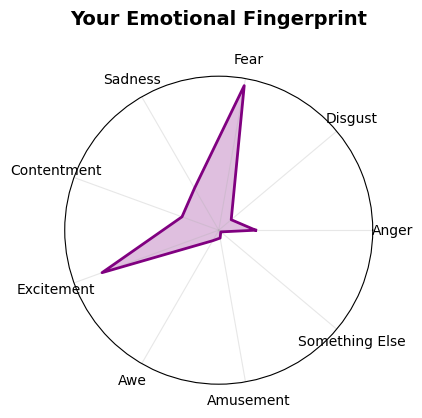

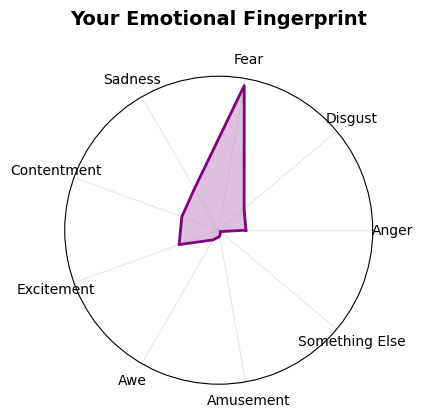

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
from tqdm import tqdm
from pathlib import Path

# ----------------------------
# Helper functions
# ----------------------------
def clean_artemis_label(s: str) -> str:
    s = str(s).strip().lower().replace('-', ' ').replace('_', ' ')
    return ' '.join(s.split())

def normalize_rows(M: np.ndarray, eps=1e-12):
    rs = M.sum(axis=1, keepdims=True) + eps
    return M / rs

def projected_gradient_nnls(P, Y, steps=1500, lr=1e-1, seed=0):
    rng = np.random.default_rng(seed)
    M = np.clip(rng.random((P.shape[1], 9))*0.1, 1e-6, None)  # n_labels x 9
    for i in tqdm(range(steps), desc="PG NNLS optimization"):
        G = 2.0 * (P.T @ (P @ M - Y))
        M -= lr * G
        M = np.clip(M, 0.0, None)
        M = normalize_rows(M)
    return M

def build_pipeline(model_dir: Path, device: int = -1):
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir)
    pipe = TextClassificationPipeline(model=mdl, tokenizer=tok, top_k=None,
                                      function_to_apply="sigmoid", device=device)
    id2label = getattr(mdl.config, "id2label", None) or {}
    labels = [id2label[i] for i in range(len(id2label))]
    return pipe, labels

def predict_proba(pipe, labels, text: str):
    out = pipe(text)[0]
    d = {o['label']: float(o['score']) for o in out}
    probs = np.array([d.get(l, 0.0) for l in labels], dtype=np.float32)
    s = probs.sum()
    return probs / (s + 1e-12)

# ----------------------------
# Load ArtEmis dataset
# ----------------------------
df_art = pd.read_csv(ARTEMIS_CSV)
assert ART_TEXT_COL in df_art.columns and ART_LABEL_COL in df_art.columns, "Check ART_TEXT_COL / ART_LABEL_COL."
df_art['_lab'] = df_art[ART_LABEL_COL].map(clean_artemis_label)
df_art = df_art[df_art['_lab'].isin(ARTEMIS_9)].reset_index(drop=True)

# ----------------------------
# Model pipeline
# ----------------------------
pipe, model_labels = build_pipeline(OUT_GOEMO / "model", device=-1)
n_labels = len(model_labels)

# Predict P (N x n_labels)
texts = df_art[ART_TEXT_COL].astype(str).tolist()
P = np.stack([predict_proba(pipe, model_labels, t) for t in tqdm(texts, desc="Predicting GoEmotions probs")], axis=0)

# Build Y (N x 9)
lab2idx = {l:i for i,l in enumerate(ARTEMIS_9)}
Y = np.zeros((len(df_art), 9), dtype=np.float32)
for i, lab in enumerate(df_art['_lab']):
    Y[i, lab2idx[lab]] = 1.0

# ----------------------------
# A1: frequency/argmax
# ----------------------------
C = np.zeros((n_labels, 9), dtype=np.float64)
gi = P.argmax(axis=1)
aj = Y.argmax(axis=1)
for g,a in zip(gi,aj): C[g,a] += 1.0
M_A1 = normalize_rows(C)

# ----------------------------
# Adjust M_A1 for high-arousal positive emotions
# ----------------------------
idx_approval = model_labels.index("approval")
idx_joy      = model_labels.index("joy")
idx_contentment = ARTEMIS_9.index("contentment")
idx_excitement  = ARTEMIS_9.index("excitement")

# Shift some weight from contentment → excitement
M_A1[idx_approval, idx_contentment] *= 0.3
M_A1[idx_approval, idx_excitement] += 0.7

M_A1[idx_joy, idx_contentment] *= 0.3
M_A1[idx_joy, idx_excitement] += 0.7

# Re-normalize rows
M_A1 = normalize_rows(M_A1)

# ----------------------------
# A2: probabilistic regression
# ----------------------------
M_A2 = projected_gradient_nnls(P, Y, steps=1500, lr=0.1, seed=0)

# ----------------------------
# Save matrices
# ----------------------------
np.save(OUT_MAP / "mapping_A1_mod.npy", M_A1.astype(np.float32))
np.save(OUT_MAP / "mapping_A2_mod.npy", M_A2.astype(np.float32))

# ----------------------------
# Visualization: Stacked Bar Plot (B)
# ----------------------------
df_A1 = pd.DataFrame(M_A1, index=model_labels, columns=ARTEMIS_9)
ax = df_A1.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.ylabel("Probability")
plt.title("A1 Mapping: Stacked Bar per GoEmotions Label")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(OUT_MAP / "mapping_A1_stacked_bar_mod.png", dpi=160)
plt.close()

df_A2 = pd.DataFrame(M_A2, index=model_labels, columns=ARTEMIS_9)
ax = df_A2.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.ylabel("Probability")
plt.title("A2 Mapping: Stacked Bar per GoEmotions Label")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(OUT_MAP / "mapping_A2_stacked_bar_mod.png", dpi=160)
plt.close()

# ----------------------------
# Top-k Table (C)
# ----------------------------
top_k = 3
print("Top-k ArtEmis labels per GoEmotions label (A2 mapping):\n")
for i, row in enumerate(M_A2):
    top_idx = row.argsort()[::-1][:top_k]
    top_labels = [(ARTEMIS_9[j], round(float(row[j]),3)) for j in top_idx]
    print(f"{model_labels[i]} → {top_labels}")

print("Top-k ArtEmis labels per GoEmotions label (A1 mapping):\n")
for i, row in enumerate(M_A1):
    top_idx = row.argsort()[::-1][:top_k]
    top_labels = [(ARTEMIS_9[j], round(float(row[j]),3)) for j in top_idx]
    print(f"{model_labels[i]} → {top_labels}")

print(f"\n[done] Saved mappings, stacked bar plot to {OUT_MAP}")

In [41]:
import numpy as np
import json

M = np.load(OUT_MAP / "mapping_A1.npy")  

def to_artemis_percent(text: str):
    # get 27-way probs from our trained model
    out = (lambda o: {d["label"]: float(d["score"]) for d in o})(
        __import__("transformers").pipelines.pipeline(
            "text-classification",
            model=str(OUT_GOEMO / "model"),
            tokenizer=str(OUT_GOEMO / "model"),
            top_k=None,
            function_to_apply="sigmoid",
            device=-1
        )(text)[0]
    )
    labels = json.loads((OUT_GOEMO / "label_list.json").read_text())
    p27 = np.array([out.get(l, 0.0) for l in labels], dtype=np.float32)
    p27 = p27 / (p27.sum() + 1e-12)
    p9 = p27 @ M
    p9 = p9 / (p9.sum() + 1e-12)

    result = {
        "probabilities": {emo: float(p) for emo, p in zip(ARTEMIS_9, p9)},
        # "percentages": {emo: float(100*p) for emo, p in zip(ARTEMIS_9, p9)}
    }

    # print nicely
    print(json.dumps(result, indent=4))

    return result


print(to_artemis_percent("I will destroy you and anyone you have ever met!"))

Device set to use cpu


{
    "probabilities": {
        "something else": 0.15098488330841064,
        "sadness": 0.10414917021989822,
        "contentment": 0.05985724553465843,
        "awe": 0.028579233214259148,
        "amusement": 0.04997720941901207,
        "excitement": 0.016924027353525162,
        "fear": 0.17758283019065857,
        "disgust": 0.13972458243370056,
        "anger": 0.2722208499908447
    }
}
{'probabilities': {'something else': 0.15098488330841064, 'sadness': 0.10414917021989822, 'contentment': 0.05985724553465843, 'awe': 0.028579233214259148, 'amusement': 0.04997720941901207, 'excitement': 0.016924027353525162, 'fear': 0.17758283019065857, 'disgust': 0.13972458243370056, 'anger': 0.2722208499908447}}


In [42]:
print(to_artemis_percent("I had such wonderful time with my friends tis weekend?"))

Device set to use cpu


{
    "probabilities": {
        "something else": 0.22250479459762573,
        "sadness": 0.02636268548667431,
        "contentment": 0.30581438541412354,
        "awe": 0.12496308982372284,
        "amusement": 0.09429250657558441,
        "excitement": 0.17560125887393951,
        "fear": 0.02564373053610325,
        "disgust": 0.018475262448191643,
        "anger": 0.006342264823615551
    }
}
{'probabilities': {'something else': 0.22250479459762573, 'sadness': 0.02636268548667431, 'contentment': 0.30581438541412354, 'awe': 0.12496308982372284, 'amusement': 0.09429250657558441, 'excitement': 0.17560125887393951, 'fear': 0.02564373053610325, 'disgust': 0.018475262448191643, 'anger': 0.006342264823615551}}


In [43]:
print(to_artemis_percent("My heart is heavy after hearing the news of the loss of my dog."))

Device set to use cpu


{
    "probabilities": {
        "something else": 0.10347592830657959,
        "sadness": 0.6421990394592285,
        "contentment": 0.05965897813439369,
        "awe": 0.031134769320487976,
        "amusement": 0.021367350593209267,
        "excitement": 0.013667040504515171,
        "fear": 0.07262168079614639,
        "disgust": 0.04354889318346977,
        "anger": 0.012326332740485668
    }
}
{'probabilities': {'something else': 0.10347592830657959, 'sadness': 0.6421990394592285, 'contentment': 0.05965897813439369, 'awe': 0.031134769320487976, 'amusement': 0.021367350593209267, 'excitement': 0.013667040504515171, 'fear': 0.07262168079614639, 'disgust': 0.04354889318346977, 'anger': 0.012326332740485668}}


In [45]:
print(to_artemis_percent("The spoilt milk in the back of the fridge made me so nauseous.. "))

Device set to use cpu


{
    "probabilities": {
        "something else": 0.19587625563144684,
        "sadness": 0.1855119913816452,
        "contentment": 0.08847774565219879,
        "awe": 0.04071454331278801,
        "amusement": 0.06332001835107803,
        "excitement": 0.023915134370326996,
        "fear": 0.13888829946517944,
        "disgust": 0.22711363434791565,
        "anger": 0.03618241474032402
    }
}
{'probabilities': {'something else': 0.19587625563144684, 'sadness': 0.1855119913816452, 'contentment': 0.08847774565219879, 'awe': 0.04071454331278801, 'amusement': 0.06332001835107803, 'excitement': 0.023915134370326996, 'fear': 0.13888829946517944, 'disgust': 0.22711363434791565, 'anger': 0.03618241474032402}}


In [46]:
print(to_artemis_percent("Oh my God!!! We won the game!!"))

Device set to use cpu


{
    "probabilities": {
        "something else": 0.10130602866411209,
        "sadness": 0.027760950848460197,
        "contentment": 0.2803623378276825,
        "awe": 0.15196719765663147,
        "amusement": 0.10789383202791214,
        "excitement": 0.28527894616127014,
        "fear": 0.027443815022706985,
        "disgust": 0.013743303716182709,
        "anger": 0.004243497271090746
    }
}
{'probabilities': {'something else': 0.10130602866411209, 'sadness': 0.027760950848460197, 'contentment': 0.2803623378276825, 'awe': 0.15196719765663147, 'amusement': 0.10789383202791214, 'excitement': 0.28527894616127014, 'fear': 0.027443815022706985, 'disgust': 0.013743303716182709, 'anger': 0.004243497271090746}}


## Diffusion

In [50]:
import torch
import torch.nn as nn
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from transformers import pipeline, CLIPTextModel, CLIPTokenizer

# -------------------------
# CONFIG
# -------------------------
device = "cpu"             
OUT_DIR = Path("emotion_sd_lora_final")
OUT_DIR.mkdir(exist_ok=True)
OUT_GOEMO = Path("out_goemo_1")   
OUT_MAP = Path("out_map_1")      

# ARTEMIS labels
ARTEMIS_9 = ['something else','sadness','contentment','awe','amusement','excitement','fear','disgust','anger']

# -------------------------
# Sanity checks / loads
# -------------------------
assert (OUT_GOEMO / "model").exists(), f"Cannot find classifier at {OUT_GOEMO / 'model'}"
assert (OUT_MAP / "mapping_A1.npy").exists(), f"Cannot find mapping at {OUT_MAP / 'mapping_A1.npy'}"

print("Loading GoEmotions classifier (pipeline)...")
classifier = pipeline(
    "text-classification",
    model=str(OUT_GOEMO / "model"),
    tokenizer=str(OUT_GOEMO / "model"),
    top_k=None,
    function_to_apply="sigmoid",
    device=-1  # CPU pipeline
)

M_A1 = np.load(OUT_MAP / "mapping_A1.npy")

Device set to use cpu


Loading GoEmotions classifier (pipeline)...


In [51]:
# -------------------------
# Load Stable Diffusion pipeline (text encoder inside)
# -------------------------
sd_model_id = "runwayml/stable-diffusion-v1-5"
print("Loading Stable Diffusion pipeline (this may take a moment)...")
pipe = StableDiffusionPipeline.from_pretrained(
    sd_model_id,
    torch_dtype=torch.float32,
    safety_checker=None
)
pipe = pipe.to(device)
pipe.enable_attention_slicing()
print("Pipeline loaded. Device:", device)

tokenizer = pipe.tokenizer

# -------------------------
# LoRA wrapper
# -------------------------
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 8.0):
        super().__init__()
        self.orig = linear
        self.r = r
        self.alpha = alpha
        if r > 0:
            self.lora_down = nn.Linear(linear.in_features, r, bias=False)
            self.lora_up = nn.Linear(r, linear.out_features, bias=False)
            nn.init.normal_(self.lora_down.weight, std=0.01)
            nn.init.zeros_(self.lora_up.weight)
        else:
            self.lora_down = None
            self.lora_up = None
        # freeze original linear parameters
        for p in self.orig.parameters():
            p.requires_grad = False
        # compute scale
        self.scale = float(alpha) / max(1, r)

        # Ensure this wrapper has parameters on same device as orig
        self.to(next(self.orig.parameters()).device)

    def forward(self, x):
        base = self.orig(x)
        if self.r > 0:
            return base + self.lora_up(self.lora_down(x)) * self.scale
        else:
            return base

def apply_lora_recursively(module: nn.Module, r: int = 8, target_types=(nn.Linear,)):
    """
    Replace Linear modules recursively with LoRALinear wrappers.
    Keeps module structure otherwise intact.
    """
    for name, child in list(module.named_children()):
        if isinstance(child, target_types):
            wrapped = LoRALinear(child, r=r, alpha=8.0)
            setattr(module, name, wrapped)
        else:
            apply_lora_recursively(child, r=r, target_types=target_types)

Loading Stable Diffusion pipeline (this may take a moment)...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded. Device: cpu


In [52]:
# -------------------------
# create a FRESH reference text encoder 
# -------------------------
print("Loading reference (original) text encoder for target embeddings...")
ref_text_encoder = CLIPTextModel.from_pretrained(sd_model_id, subfolder="text_encoder").to(device)
ref_text_encoder.eval()

# -------------------------
# Apply LoRA to the pipeline's text_encoder
# -------------------------
print("Applying LoRA wrappers to pipeline's text encoder (this modifies pipe.text_encoder in-place)...")
apply_lora_recursively(pipe.text_encoder, r=8)
# move the modified encoder to device (already should be)
pipe.text_encoder = pipe.text_encoder.to(device)

# Show trainable param counts
total_params = sum(p.numel() for p in pipe.text_encoder.parameters())
trainable_params = sum(p.numel() for p in pipe.text_encoder.parameters() if p.requires_grad)
print(f"text_encoder total params: {total_params:,}; trainable (LoRA) params: {trainable_params:,}")


Loading reference (original) text encoder for target embeddings...
Applying LoRA wrappers to pipeline's text encoder (this modifies pipe.text_encoder in-place)...
text_encoder total params: 124,387,584; trainable (LoRA) params: 39,369,984


In [53]:
# -------------------------
# Prepare emotion training data (keywords -> captions)
# -------------------------
emotion_keywords = ["neutral", "sadness", "contentment", "awe", "amusement", "excitement", "fear", "disgust", "anger"]
emotion_captions = [
    "neutral abstract painting, soft colors, calm atmosphere",
    "deep sadness, tears on face, rainy day, blue melancholy, lonely figure",
    "warm golden sunset over peaceful lake, calm, serene, contentment",
    "majestic mountains, divine light rays, breathtaking awe and wonder",
    "playful joy, laughter, bright colors, amusement park, fun",
    "explosive excitement, fireworks in sky, celebration, vibrant energy",
    "terrifying dark nightmare, shadows, horror movie, primal fear",
    "rotting flesh, nausea, grotesque decay, disgusting horror",
    "violent rage, red and black chaos, pure anger, fury explosion"
]

# -------------------------
#  pooled embedding extraction 
# -------------------------
def pooled_from_encoder(texts, encoder, tokenizer, device="cpu"):
    enc = tokenizer(texts, padding="max_length", truncation=True, max_length=77, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = encoder(**enc)
        # prefer pooler_output if exists
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            pooled = out.pooler_output
        else:
            pooled = out.last_hidden_state.mean(dim=1)
    return pooled  # (B, dim)

# -------------------------
# Compute targets using reference encoder 
# -------------------------
print("Computing target pooled embeddings using the reference (unmodified) text encoder...")
targets = pooled_from_encoder(emotion_captions, ref_text_encoder, tokenizer, device=device)  # (9, dim)
targets = targets.detach()

Computing target pooled embeddings using the reference (unmodified) text encoder...


In [54]:
# -------------------------
# Set up optimizer to update only trainable parameters (LoRA parts)
# -------------------------
lora_params = [p for p in pipe.text_encoder.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(lora_params, lr=5e-4, weight_decay=0.0)

# -------------------------
# Training LoRA 
# -------------------------
print("Training LoRA adapters to map keywords -> caption embeddings (tiny run).")
pipe.text_encoder.train()
loss_fn = nn.MSELoss()

epochs = 30   
for ep in range(epochs):
    epoch_loss = 0.0
    for idx, kw in enumerate(emotion_keywords):
        # encode short keyword through LoRA-enabled text_encoder
        enc = tokenizer([kw], padding="max_length", truncation=True, max_length=77, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = pipe.text_encoder(**enc)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            pooled = out.pooler_output  # (1, dim)
        else:
            pooled = out.last_hidden_state.mean(dim=1)

        tgt = targets[idx:idx+1].to(device)
        loss = loss_fn(pooled, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += float(loss.detach().cpu().item())
    if (ep + 1) % 5 == 0:
        print(f"  Epoch {ep+1:03d} avg loss: {epoch_loss/len(emotion_keywords):.6f}")

pipe.text_encoder.eval()
print("LoRA training complete. Saved a copy of LoRA-enabled text_encoder state_dict.")
torch.save(pipe.text_encoder.state_dict(), OUT_DIR / "text_encoder_with_lora_state.pth")


Training LoRA adapters to map keywords -> caption embeddings (tiny run).
  Epoch 005 avg loss: 0.210523
  Epoch 010 avg loss: 0.046517
  Epoch 015 avg loss: 0.011176
  Epoch 020 avg loss: 0.011499
  Epoch 025 avg loss: 0.000892
  Epoch 030 avg loss: 0.002168
LoRA training complete. Saved a copy of LoRA-enabled text_encoder state_dict.


In [59]:
# -------------------------
# Inference: generate images using classifier -> mapping -> prompt
# -------------------------
print("\nGenerating images using the LoRA-enabled pipeline (may be slow on CPU)...")

def text_to_artemis_probs(text):
    """
    Converts a sentence to a 9-dimensional ARTEMIS probability vector.
    Includes a manual adjustment to map high-arousal positive emotions
    (approval, joy) more strongly to excitement.
    """
    # raw GoEmotions 27-class scores
    res = classifier(text)[0]
    labels27 = json.loads((OUT_GOEMO / "label_list.json").read_text())
    score_dict = {r['label']: r['score'] for r in res}
    p27 = np.array([score_dict.get(l, 0.0) for l in labels27], dtype=np.float32)
    
    if p27.sum() > 0:
        p27 /= p27.sum()
    else:
        p27 = np.ones_like(p27) / len(p27)
    
    # map 27 → 9
    p9 = p27 @ M_A1

    idx_approval = labels27.index("approval")
    idx_joy      = labels27.index("joy")
    idx_contentment = ARTEMIS_9.index("contentment")
    idx_excitement  = ARTEMIS_9.index("excitement")
    
    p9[idx_excitement] += p27[idx_approval]*0.7 + p27[idx_joy]*0.7
    p9[idx_contentment] -= p27[idx_approval]*0.5 + p27[idx_joy]*0.5

    # clip & normalize
    p9 = np.clip(p9, 1e-6, None)
    p9 /= p9.sum()
    
    return p9


emotion_style = {
    "anger": "furious volcanic eruption of rage, dark crimson and black abstract expressionism, "
             "Franz Kline and de Kooning style, violent slashing brush strokes, raw emotional fury, "
             "dramatic chiaroscuro, museum-quality oil painting masterpiece",
    
    "disgust": "grotesque decaying flesh and organic matter, sickly green-yellow pus, "
               "visceral revulsion, Francis Bacon distorted bodies, hyper-detailed surreal horror, "
               "nauseating atmosphere, museum-quality oil painting",
    
    "fear": "primordial terror in the dark, shadowy figures emerging from mist, "
             "Zdzisław Beksiński dystopian nightmare, eerie blue moonlight, creeping dread, "
             "psychological horror masterpiece, museum-quality oil painting",
    
    "sadness": "profound melancholy, lone figure in pouring rain under streetlight, "
               "Edward Hopper solitude, deep blues and muted grays, tears on face, "
               "heartbreaking cinematic atmosphere, museum-quality oil painting",
    
    "contentment": "warm golden hour glow over peaceful meadow, soft pastel skies, "
                   "Claude Monet impressionism, gentle breeze, pure tranquility and inner peace, "
                   "serene masterpiece, museum-quality oil painting",
    
    "excitement": "explosive joy and celebration, massive colorful fireworks bursting across the night sky, "
                  "vibrant neon colors, dynamic Futurist energy, electric pop-art style, "
                  "pure exhilaration and life force, high-energy masterpiece",
    
    "awe": "transcendent cosmic wonder, majestic snow-capped mountains bathed in divine golden light rays, "
           "Caspar David Friedrich romanticism, sublime overwhelming scale, "
           "breathtaking spiritual beauty, museum-quality oil painting",
    
    "amusement": "playful whimsical delight, colorful carnival of laughter and joy, "
                 "Henri Matisse vibrant colors, dancing figures with big smiles, "
                 "lighthearted fun and innocent happiness, cheerful masterpiece",
    
    "something else": "ethereal abstract meditation, soft pastel color field gradients, "
                      "Mark Rothko contemplative calm, emotional ambiguity, "
                      "pure abstract expression, no figures, serene and mysterious"
}

sentences = [
    "I will destroy you and anyone you have ever met!",
    "I had a good time with my friends this weekend",
    "My heart is heavy after hearing the news of the loss of my dog.",
    "Oh my God!!! We won the game!!",
    "The spoilt milk in the back of the fridge made me so nauseous.."
]

for i, s in enumerate(sentences, 1):
    p9 = text_to_artemis_probs(s)
    dominant = ARTEMIS_9[int(np.argmax(p9))]
    confidence = p9.max()
    style = emotion_style[dominant]  

    if dominant in ["excitement", "amusement"]:
        prefix = "vibrant emotionally intense masterpiece, highly detailed, dramatic lighting, "
    elif dominant == "something else":
        prefix = "pure abstract expression, "
    else:
        prefix = "museum quality oil painting with visible brush strokes, highly detailed, dramatic lighting, "
    
    prompt = f"{prefix}expressing intense {dominant}, {style}, emotional masterpiece, 8k resolution"

    print(f"\n[{i}/5] Sent: {s}")
    print(f"[{i}/9] Detected: {dominant.upper():12}")
    #print("  Detected dominant:", dominant)
    print("  Prompt (truncated):", prompt[:120])

    # Generate
    with torch.no_grad():
        out = pipe(prompt, num_inference_steps=25, guidance_scale=7.5, height=512, width=512)
        image = out.images[0]

    fname = OUT_DIR / f"final_art_enc_{i}_{dominant}.png"
    image.save(fname)
    print("  Saved:", fname)

print("\nFinished. Results saved to:", OUT_DIR)


Generating images using the LoRA-enabled pipeline (may be slow on CPU)...

[1/5] Sent: I will destroy you and anyone you have ever met!
[1/9] Detected: ANGER       
  Prompt (truncated): museum quality oil painting with visible brush strokes, highly detailed, dramatic lighting, expressing intense anger, fu


  0%|          | 0/25 [00:00<?, ?it/s]

  Saved: emotion_sd_lora_final/final_art_enc_1_anger.png

[2/5] Sent: I had a good time with my friends this weekend
[2/9] Detected: EXCITEMENT  
  Prompt (truncated): vibrant emotionally intense masterpiece, highly detailed, dramatic lighting, expressing intense excitement, explosive jo


  0%|          | 0/25 [00:00<?, ?it/s]

  Saved: emotion_sd_lora_final/final_art_enc_2_excitement.png

[3/5] Sent: My heart is heavy after hearing the news of the loss of my dog.
[3/9] Detected: SADNESS     
  Prompt (truncated): museum quality oil painting with visible brush strokes, highly detailed, dramatic lighting, expressing intense sadness, 


...

  Saved: emotion_sd_lora_final/final_art_enc_3_sadness.png

[4/5] Sent: Oh my God!!! We won the game!!
[4/9] Detected: EXCITEMENT  
  Prompt (truncated): vibrant emotionally intense masterpiece, highly detailed, dramatic lighting, expressing intense excitement, explosive jo


  0%|          | 0/25 [00:00<?, ?it/s]

  Saved: emotion_sd_lora_final/final_art_enc_4_excitement.png

[5/5] Sent: The spoilt milk in the back of the fridge made me so nauseous..
[5/9] Detected: DISGUST     
  Prompt (truncated): museum quality oil painting with visible brush strokes, highly detailed, dramatic lighting, expressing intense disgust, 


  0%|          | 0/25 [00:00<?, ?it/s]

  Saved: emotion_sd_lora_final/final_art_enc_5_disgust.png

Finished. Results saved to: emotion_sd_lora_final


#### Evaluation

In [60]:
# ============================================================
# EVALUATION: CLIPScore
# ============================================================

import torch
from PIL import Image
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from pathlib import Path
from tqdm import tqdm

print("\n=== Starting Evaluation ===")

# ------------------------------------------------------------
# Load CLIP model
# ------------------------------------------------------------
clip_model_id = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)

# ------------------------------------------------------------
# Helper: load image as CLIP tensor
# ------------------------------------------------------------
def load_image_for_clip(path):
    img = Image.open(path).convert("RGB")
    return img

# ------------------------------------------------------------
# 1. CLIPScore: text-image similarity
# ------------------------------------------------------------
def compute_clip_score(prompt, image):
    inputs = clip_processor(text=[prompt], images=image, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = clip_model(**inputs)
        # cosine similarity between text & image embeddings
        image_feat = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
        text_feat = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)
        score = (image_feat * text_feat).sum(dim=-1).cpu().item()
    return float(score)


=== Starting Evaluation ===


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [61]:
# ------------------------------------------------------------
# 2. Emotion Alignment Score:
# classifier(text) vs classifier_on_clip(image)
# ------------------------------------------------------------
def compute_emotion_alignment(text, image):
    # text → ARTEMIS 9-vector
    p_text = text_to_artemis_probs(text)

    # image → CLIP text description → classifier
    clip_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        img_embeds = clip_model.get_image_features(**clip_inputs)[0]

    # Convert CLIP image embedding → pseudo-caption
    scores = {}
    for emo in ARTEMIS_9:
        emo_inputs = clip_processor(text=[emo], return_tensors="pt").to(device)
        with torch.no_grad():
            emo_emb = clip_model.get_text_features(**emo_inputs)[0]
        emo_emb = emo_emb / emo_emb.norm()
        img_emb = img_embeds / img_embeds.norm()
        scores[emo] = float((emo_emb * img_emb).sum().cpu().item())

    # convert to probability distribution
    emo_vec = np.array(list(scores.values()), dtype=np.float32)
    emo_vec = np.maximum(emo_vec, 1e-6)
    emo_vec /= emo_vec.sum()

    # alignment = cosine similarity of the two 9-d vectors
    p_text_norm = p_text / (np.linalg.norm(p_text) + 1e-9)
    p_img_norm = emo_vec / (np.linalg.norm(emo_vec) + 1e-9)

    return float(np.dot(p_text_norm, p_img_norm))

In [62]:
# ------------------------------------------------------------
# 3. FID Score 
# ------------------------------------------------------------
# Uses a simplified Numpy InceptionV3 embedding version

from torchvision.models import inception_v3

fid_model = inception_v3(pretrained=True, transform_input=False).to(device)
fid_model.eval()

fid_tf = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor()
])

def get_inception_embedding(img):
    img = fid_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = fid_model(img)
    return pred.squeeze().cpu().numpy()

def compute_fid(real_folder, gen_folder):
    real_paths = sorted([p for p in Path(real_folder).glob("*.jpg")])
    gen_paths  = sorted([p for p in Path(gen_folder).glob("*.png")])

    real_embs = []
    gen_embs = []

    for p in tqdm(real_paths, desc="Real FID embeds"):
        img = Image.open(p).convert("RGB")
        real_embs.append(get_inception_embedding(img))
    for p in tqdm(gen_paths, desc="Generated FID embeds"):
        img = Image.open(p).convert("RGB")
        gen_embs.append(get_inception_embedding(img))

    real_embs = np.array(real_embs)
    gen_embs = np.array(gen_embs)

    # Means & covariances
    mu1, mu2 = real_embs.mean(axis=0), gen_embs.mean(axis=0)
    sigma1 = np.cov(real_embs, rowvar=False)
    sigma2 = np.cov(gen_embs, rowvar=False)

    # Compute FID
    diff = mu1 - mu2
    covmean = np.linalg.sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

/Users/saeedesai/Desktop/UMD DS/DATA612 PROJECT/dl_proj_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/saeedesai/Desktop/UMD DS/DATA612 PROJECT/dl_proj_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/saeedesai/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:06<00:00, 16.0MB/s] 


In [63]:
# ============================================================
# RUN ALL EVALUATIONS
# ============================================================

results = []

for i, s in enumerate(sentences, 1):
    img_path = OUT_DIR / f"final_art_enc_{i}_{ARTEMIS_9[int(np.argmax(text_to_artemis_probs(s)))]}.png"
    img = load_image_for_clip(img_path)

    clip_score = compute_clip_score(s, img)
    alignment  = compute_emotion_alignment(s, img)

    results.append({
        "sentence": s,
        "image": str(img_path),
        "clip_score": clip_score,
        "emotion_alignment": alignment,
    })

print("\n=== Per-Image Evaluation ===")
for r in results:
    print("\nSentence:", r["sentence"])
    print("Image:", r["image"])
    print(f"CLIPScore: {r['clip_score']:.4f}")
    print(f"Emotion Alignment: {r['emotion_alignment']:.4f}")


=== Per-Image Evaluation ===

Sentence: I will destroy you and anyone you have ever met!
Image: emotion_sd_lora_final/final_art_enc_1_anger.png
CLIPScore: 0.1853
Emotion Alignment: 0.8586

Sentence: I had a good time with my friends this weekend
Image: emotion_sd_lora_final/final_art_enc_2_excitement.png
CLIPScore: 0.1901
Emotion Alignment: 0.7004

Sentence: My heart is heavy after hearing the news of the loss of my dog.
Image: emotion_sd_lora_final/final_art_enc_3_sadness.png
CLIPScore: 0.1546
Emotion Alignment: 0.5222

Sentence: Oh my God!!! We won the game!!
Image: emotion_sd_lora_final/final_art_enc_4_excitement.png
CLIPScore: 0.1735
Emotion Alignment: 0.6667

Sentence: The spoilt milk in the back of the fridge made me so nauseous..
Image: emotion_sd_lora_final/final_art_enc_5_disgust.png
CLIPScore: 0.1863
Emotion Alignment: 0.8598


### User interface

In [76]:
# ================================
# SIMPLE GRADIO INTERFACE
# ================================
import gradio as gr
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import time

def generate(sentence):
    # 1. Emotion classification
    res = classifier(sentence)[0]
    
    with open(OUT_GOEMO / "label_list.json") as f:
        labels = json.load(f)
        
    p27 = np.array([next((r['score'] for r in res if r['label']==l), 0) for l in labels])
    p27 /= p27.sum() + 1e-8
    
    # 27 → 9
    p27 += 1e-6
    p27 /= p27.sum()
    p9 = p27 @ M_A1
    p9 += 1e-6
    p9 /= p9.sum()
    dominant = ARTEMIS_9[np.argmax(p9)]
    
    style = emotion_style.get(dominant, emotion_style["something else"])
    if dominant in ["excitement", "amusement"]:
        prefix = "vibrant emotionally intense masterpiece, highly detailed, dramatic lighting, "
    elif dominant == "something else":
        prefix = "pure abstract expression, "
    else:
        prefix = "museum quality oil painting with visible brush strokes, highly detailed, dramatic lighting, "
    
    
    # creative card HTML
    emotion_html = f"""
    <div style="
        background: linear-gradient(135deg, #6a11cb, #2575fc);
        padding: 20px;
        border-radius: 15px;
        color: white;
        font-size: 26px;
        text-align: center;
        font-weight: bold;
        box-shadow: 0px 4px 15px rgba(0,0,0,0.3);
        margin-top: 20px;
    ">
        <div>✨ Detected Emotion ✨</div>
        <div style="font-size:40px; margin-top:10px;">{dominant.upper()}</div>
    </div>
    """
    
    # Yield emotion immediately
    yield None, emotion_html
    
    # rotating “while painting” messages
    msgs = [
        "Mixing colors from your feelings… 🎨",
        "Letting your soul guide the brush… ✨",
        "Shaping emotion into texture… 🌌",
        "Painting what words cannot say… 💫",
        "Almost there — beauty takes time… ⏳"
    ]
    
    # show rotating messages while generating
    for m in msgs:
        yield None, emotion_html + f"<p style='text-align:center; color:#666;'>{m}</p>"
        time.sleep(1.2)
    
    prompt = f"{prefix}expressing intense {dominant}, {style}, emotional masterpiece, 8k resolution"

    with torch.no_grad():
        image = pipe(prompt, num_inference_steps=28, guidance_scale=8.0).images[0]

    # final output
    yield image, emotion_html


# ======================== GRADIO INTERFACE ========================
with gr.Blocks(
    theme=gr.themes.Soft(),
    css="""
    .title {font-size: 48px; font-weight: 900;
            background: linear-gradient(90deg,#ff7eb3,#ff758c,#ff7eb3);
            -webkit-background-clip:text; -webkit-text-fill-color:transparent;
            text-align:center; margin-bottom:10px;}
    .subtitle {text-align:center; font-size:18px; color:#444;}
    .loading-box {text-align:center; font-size:20px; padding:20px; color:#555;}
    """
) as demo:

    gr.HTML("<h1 class='title'>Emotion → Art</h1>")
    gr.HTML("<p class='subtitle'>Your feelings, transformed into a masterpiece.</p>")
    
    with gr.Row():
        with gr.Column():
            textbox = gr.Textbox(label="Speak your emotion", lines=4)
            btn = gr.Button("Paint My Soul 🎨", variant="primary")
        with gr.Column():
            img = gr.Image(label="Generated Artwork", height=512)
    
    emotion_html = gr.HTML("")
    
    btn.click(generate, inputs=textbox, outputs=[img, emotion_html])

print("Launching your emotional art gallery...")
demo.launch(share=True, server_name="0.0.0.0", server_port=7875)

Launching your emotional art gallery...
* Running on local URL:  http://0.0.0.0:7875


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


* Running on public URL: https://fe0eb450c5a02076f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]